Running long simulation (5000 ms)...

════════════════════════════════════════════════════════
  BRAIN  |  52 neurons  445 synapses  3 regions  3645 total spikes  state=wake  pressure=0.000
════════════════════════════════════════════════════════

  [Thalamus]  8E + 4I  |  17 internal synapses  |  avg fatigue = 0.156
  E spikes: 561   I spikes: 401
    N00[E] L0  ←in    73  |████████████████████████████████████████
    N01[E] L0  ←in    73  |████████████████████████████████████████
    N02[E] L0  ←in    77  |████████████████████████████████████████
    N03[E] L0  ←in    76  |████████████████████████████████████████
    N04[E] L0  ←in    74  |████████████████████████████████████████
    N05[E] L0  ←in    51  |████████████████████████████████████████
    N06[E] L0  ←in    69  |████████████████████████████████████████
    N07[E] L0  ←in    68  |████████████████████████████████████████
    N08[I]            105  |████████████████████████████████████████
    N09[I]            137  |████████

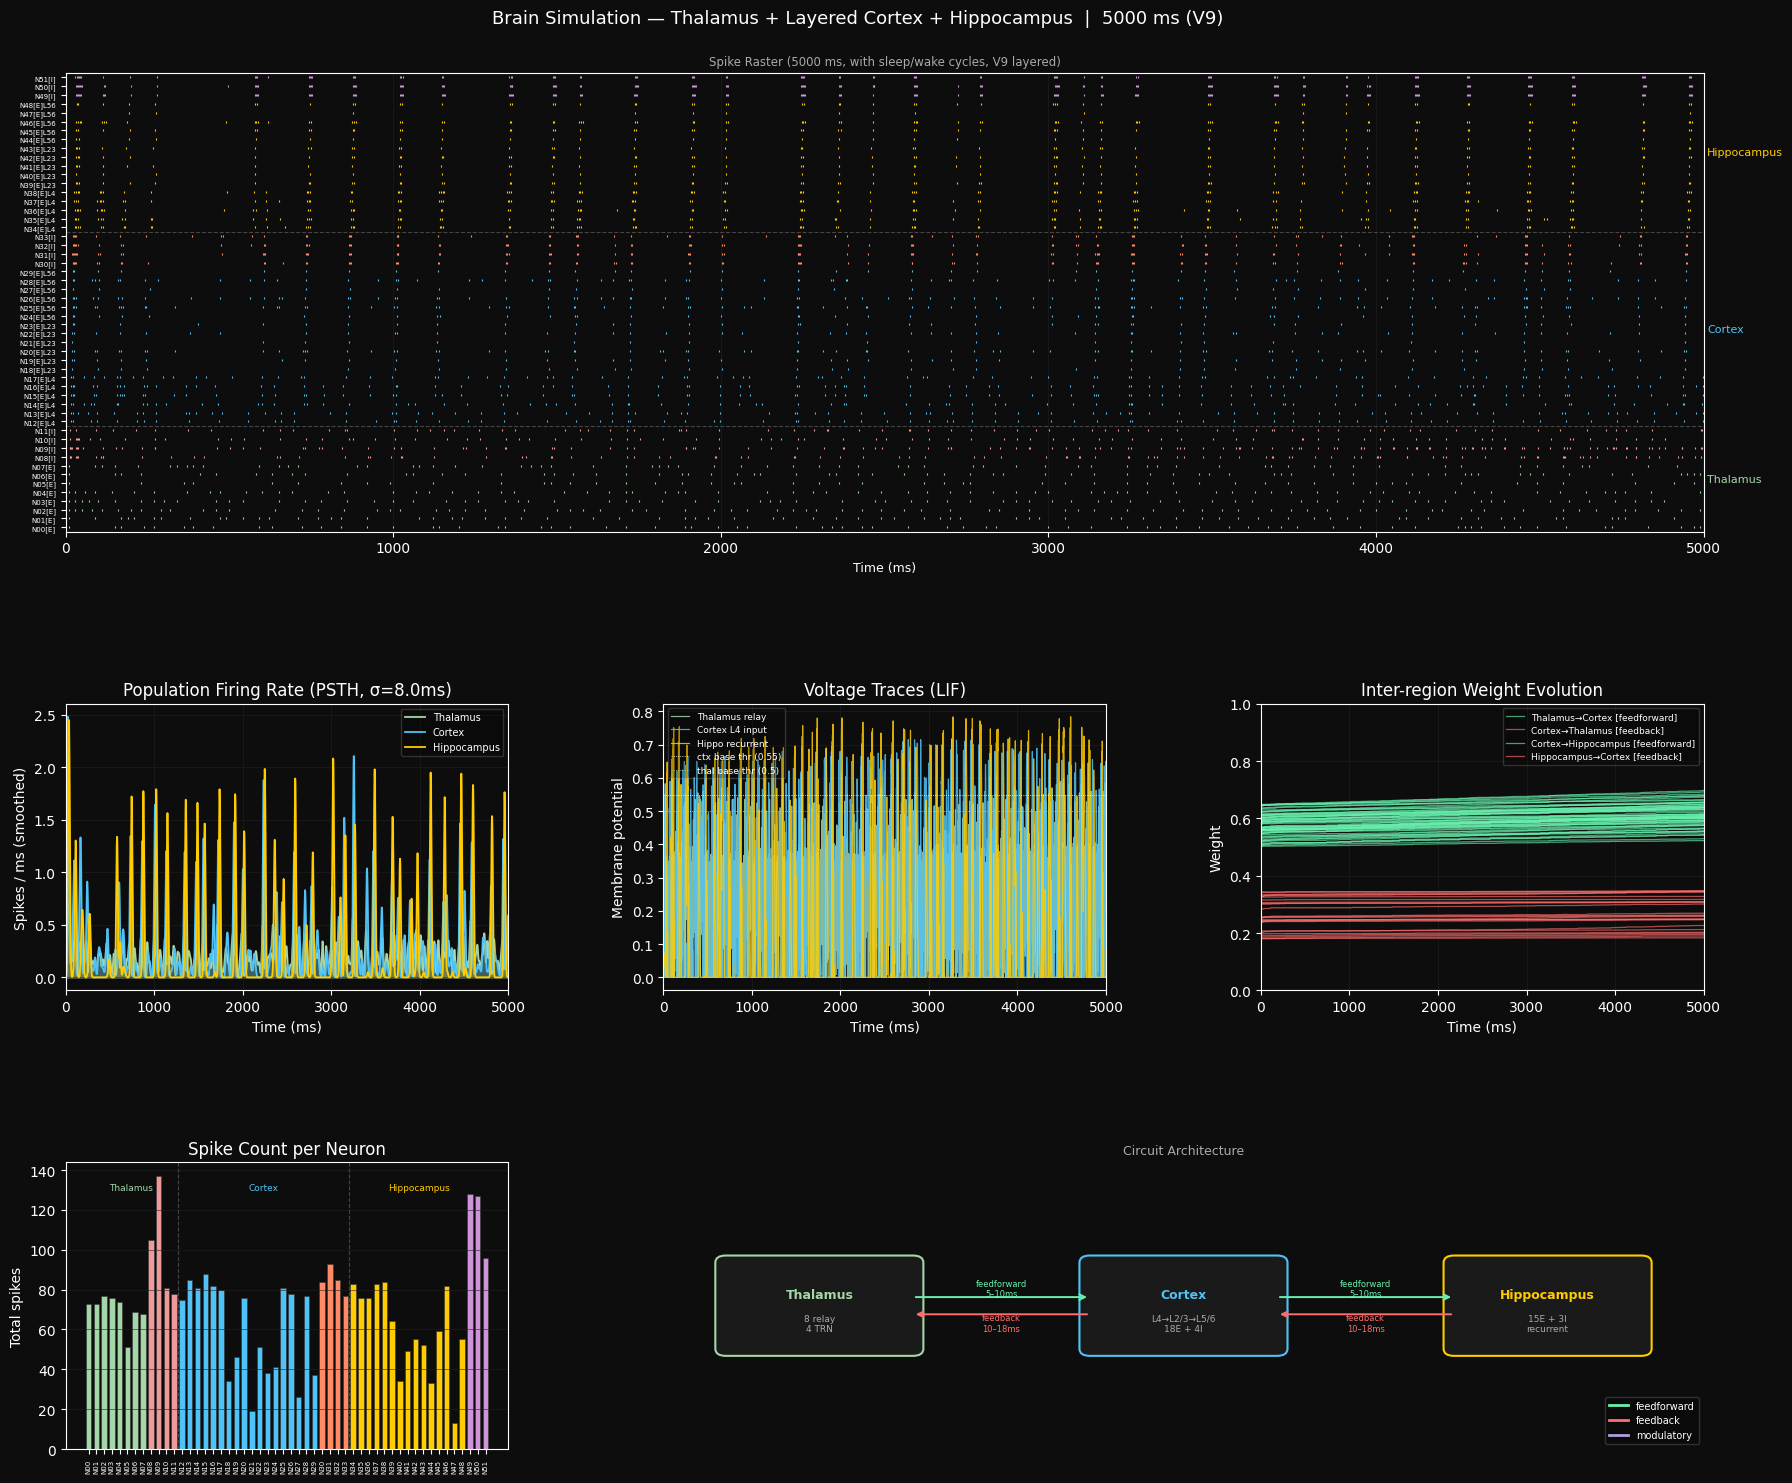

Plot saved → brain_sim_long_V9.png (also shown above)


In [1]:
import numpy as np

# Global neuron ID counter
_next_id = 0
def _uid():
    global _next_id
    _next_id += 1
    return _next_id - 1

# ======================================================================
#  PROJECTION TYPE PRESETS
# ======================================================================
PROJECTION = {
    "feedforward": dict(
        weight_range = (0.50, 0.65),
        delay_range  = (5,  10),
        learn_rate   = 0.001,
    ),
    "feedback": dict(
        weight_range = (0.15, 0.35),
        delay_range  = (10, 18),
        learn_rate   = 0.001,
    ),
    "modulatory": dict(
        weight_range = (0.05, 0.20),
        delay_range  = (15, 25),
        learn_rate   = 0.0005,
    ),
}

def gamma_delay(delay_range):
    """Sample a biologically realistic delay (right‑skewed distribution)."""
    min_d, max_d = delay_range
    raw = np.random.gamma(2.0, 1.5)
    delay = int(round(min_d + raw))
    delay = max(min_d, min(delay, max_d))
    return delay

# ======================================================================
#  BrainNeuron – same as V8
# ======================================================================
class BrainNeuron:
    def __init__(self, tau_m=20.0, threshold=0.55, v_reset=0.0,
                 refractory=5, noise_std=0.008, target_rate=15.0,
                 adapt_gain=0.005, adapt_tau=200.0, layer=0):
        self.id              = _uid()
        self.tau_m           = tau_m
        self.base_threshold  = threshold
        self.v_reset         = v_reset
        self.v               = v_reset
        self.refractory      = refractory
        self.last_spike_time = -1000
        self.noise_std       = noise_std
        self.tau_noise       = 5.0
        self.eta             = 0.0
        self.spike_times     = []
        self.v_history       = []
        self.record_history  = True
        self._pending_I      = 0.0
        self.layer           = layer            # 4, 23, or 56

        self.g_ahp           = 0.0
        self.adapt_gain      = adapt_gain
        self.adapt_tau       = adapt_tau

        # Homeostatic scaling
        self.target_rate     = target_rate
        self._scale          = np.random.uniform(0.85, 1.15)
        self._homeo_eta      = 0.05
        self._spike_counter  = 0
        self._rate_estimate  = target_rate

        # Fatigue / sleep‑pressure system
        self.fatigue         = 0.0
        self.max_fatigue     = 0.3
        self.spike_cost      = 0.035
        self.fatigue_recovery_wake = 0.0005
        self.fatigue_recovery_sleep = 0.005

        # --- Conductance‑based synaptic variables ---
        self.g_ampa = 0.0
        self.g_gaba = 0.0
        self.tau_ampa = 5.0
        self.tau_gaba = 10.0
        self.E_exc = 0.85
        self.E_inh = -0.15

    def receive(self, I):
        self._pending_I += I * self._scale if I > 0 else I

    def step(self, t, dt=1.0):
        self.eta += dt * (-self.eta / self.tau_noise) + \
                    np.sqrt(2 * dt / self.tau_noise) * self.noise_std * np.random.normal()
        self.g_ahp += dt * (-self.g_ahp / self.adapt_tau)
        self.g_ampa += dt * (-self.g_ampa / self.tau_ampa)
        self.g_gaba += dt * (-self.g_gaba / self.tau_gaba)

        if t - self.last_spike_time < self.refractory:
            self._pending_I = 0.0
            if self.record_history:
                self.v_history.append(self.v_reset)
            return 0

        effective_threshold = self.base_threshold + self.fatigue
        I_ampa = self.g_ampa * (self.E_exc - self.v)
        I_gaba = self.g_gaba * (self.E_inh - self.v)
        effective_I = self._pending_I + I_ampa + I_gaba - self.g_ahp + self.eta
        self.v += dt * (-self.v / self.tau_m + effective_I)
        self.v  = max(self.v, self.v_reset)
        self._pending_I = 0.0

        if self.v >= effective_threshold:
            if self.record_history:
                self.v_history.append(effective_threshold)
            self.last_spike_time = t
            self.v = self.v_reset
            self.spike_times.append(t)
            self.g_ahp += self.adapt_gain
            self.fatigue = min(self.fatigue + self.spike_cost, self.max_fatigue)
            self._spike_counter += 1
            return 1

        if self.record_history:
            self.v_history.append(self.v)
        return 0

    def homeostatic_step(self, window_ms=100):
        if window_ms <= 0:
            return
        recent_rate = self._spike_counter / (window_ms * 0.001)
        self._rate_estimate = 0.9 * self._rate_estimate + 0.1 * recent_rate
        error = self.target_rate - self._rate_estimate
        self._scale += self._homeo_eta * error * 0.02
        self._scale = np.clip(self._scale, 0.2, 5.0)
        self._spike_counter = 0

    @property
    def firing_rate(self):
        return len(self.spike_times)

    def __repr__(self):
        return f"N{self.id:02d}"

# ======================================================================
#  Synapse – same as V8
# ======================================================================
class Synapse:
    def __init__(self, pre, post, weight=None, synapse_type="excitatory",
                 delay=1, learn_rate=0.01,
                 tau_ltp=17.0, tau_ltd=34.0, ltd_factor=0.65,
                 U=0.5, tau_facil=50.0, tau_rec=200.0,
                 use_stp=True):
        self.pre          = pre
        self.post         = post
        self.weight       = weight if weight is not None else np.random.uniform(0.3, 0.6)
        self.sign         = 1.0 if synapse_type == "excitatory" else -1.0
        self.synapse_type = synapse_type
        self.delay        = delay
        self.learn_rate   = learn_rate
        self.tau_ltp      = tau_ltp
        self.tau_ltd      = tau_ltd
        self.ltd_factor   = ltd_factor
        self._buffer      = [(0.0, None)] * delay
        self.use_stp      = use_stp
        self.U            = U
        self.tau_facil    = tau_facil
        self.tau_rec      = tau_rec
        self.A_prev       = 1.0
        self.u_prev       = U

    def deliver(self):
        g_inc, syn_type = self._buffer.pop(0)
        if g_inc != 0.0 and syn_type is not None:
            if syn_type == "excitatory":
                self.post.g_ampa += g_inc
            else:
                self.post.g_gaba += g_inc

    def enqueue(self, pre_fired):
        if pre_fired:
            if not self.use_stp or self.synapse_type == "inhibitory":
                g_inc = self.weight
            else:
                R_eff = self.u_prev * self.A_prev * self.weight
                self.u_prev = self.u_prev + self.U * (1.0 - self.u_prev) * (1.0 - np.exp(-1.0 / self.tau_facil))
                self.A_prev = self.A_prev - R_eff + (1.0 - self.A_prev) * (1.0 - np.exp(-1.0 / self.tau_rec))
                self.A_prev = max(0.0, min(self.A_prev, 1.0))
                g_inc = R_eff
            self._buffer.append((g_inc, self.synapse_type))
        else:
            self._buffer.append((0.0, None))

    def step(self, dt=1.0):
        if not self.use_stp:
            return
        self.A_prev += dt * ((1.0 - self.A_prev) / self.tau_rec)
        self.u_prev += dt * (-(self.u_prev - self.U) / self.tau_facil)
        self.A_prev = max(0.0, min(self.A_prev, 1.0))
        self.u_prev = max(self.U, min(self.u_prev, 1.0))

    def stdp_update(self, t_post):
        delta_t = t_post - self.pre.last_spike_time
        if delta_t > 0:
            dw = self.learn_rate * np.exp(-delta_t / self.tau_ltp)
        else:
            dw = -self.learn_rate * self.ltd_factor * np.exp(delta_t / self.tau_ltd)
        self.weight = np.clip(self.weight + dw, 0.0, 2.0)

# ======================================================================
#  BrainRegion – now with LAYER‑SPECIFIC WIRING (V9)
# ======================================================================
class BrainRegion:
    def __init__(self, name, n_excitatory, n_inhibitory, p_connect=0.30,
                 recurrent=False, tau_m=20.0, threshold=0.55,
                 noise_std=0.008, refractory=5,
                 target_rate=15.0, target_rate_i=20.0):
        self.name              = name
        self.internal_synapses = []

        # Assign cortical layers: L4 (input), L2/3 (hidden), L5/6 (output)
        self.excitatory = []
        for i in range(n_excitatory):
            if i < n_excitatory // 3:
                layer = 4          # Layer 4 – input
            elif i < 2 * n_excitatory // 3:
                layer = 23         # Layer 2/3 – processing
            else:
                layer = 56         # Layer 5/6 – output
            self.excitatory.append(
                BrainNeuron(tau_m=tau_m, threshold=threshold,
                            noise_std=noise_std, refractory=refractory,
                            target_rate=target_rate,
                            adapt_gain=0.012, adapt_tau=200.0,
                            layer=layer))

        self.inhibitory = [BrainNeuron(tau_m=tau_m*0.65, threshold=threshold*0.80,
                                       noise_std=noise_std, refractory=max(2,refractory-2),
                                       target_rate=target_rate_i,
                                       adapt_gain=0.008, adapt_tau=150.0, layer=0)
                           for _ in range(n_inhibitory)]
        self.neurons = self.excitatory + self.inhibitory

        n_in = max(1, n_excitatory // 3)
        n_out = max(1, n_excitatory // 3)
        self.input_neurons  = self.excitatory[:n_in]
        self.output_neurons = self.excitatory[-n_out:]

        self._wire(p_connect, recurrent)

    def _wire(self, p, recurrent):
        # Layer‑boost factors for E→E connections
        boost_E_E = {
            (4, 23): 2.0,      # L4 → L2/3: very strong (main feedforward)
            (23, 56): 1.8,     # L2/3 → L5/6: strong (feedforward to output)
            (23, 23): 1.2,     # L2/3 → L2/3: moderate (horizontal)
            (56, 56): 1.2,     # L5/6 → L5/6: moderate (recurrent output)
            (4, 56): 0.6,      # L4 → L5/6: weak (direct shortcut)
            (56, 23): 0.5,     # L5/6 → L2/3: weak (feedback)
            (4, 4): 0.5,       # L4 → L4: very weak
        }

        for pre in self.neurons:
            is_exc_pre = pre in self.excitatory
            pre_layer = getattr(pre, 'layer', 0)
            for post in self.neurons:
                if pre is post:
                    continue
                is_exc_post = post in self.excitatory
                post_layer = getattr(post, 'layer', 0)

                if   is_exc_pre and is_exc_post:   prob = p * 0.80
                elif is_exc_pre and not is_exc_post: prob = p * 2.0    # strong E→I
                elif not is_exc_pre and is_exc_post: prob = p * 1.50
                else:                                prob = p * 0.15

                # Apply layer‑specific boost for E→E
                if is_exc_pre and is_exc_post:
                    key = (pre_layer, post_layer)
                    if key in boost_E_E:
                        prob *= boost_E_E[key]

                if recurrent and is_exc_pre and is_exc_post:
                    prob = min(prob * 1.5, 0.90)

                if np.random.random() < prob:
                    syn_type = "excitatory" if is_exc_pre else "inhibitory"
                    if syn_type == "excitatory":
                        w = np.random.uniform(0.50, 0.70)
                    elif is_exc_post:
                        w = np.random.uniform(0.60, 0.90)
                    else:
                        w = np.random.uniform(0.10, 0.25)
                    delay = gamma_delay((1, 4))
                    self.internal_synapses.append(
                        Synapse(pre, post, weight=w,
                                synapse_type=syn_type, delay=delay,
                                use_stp=(syn_type == "excitatory")))

        # Minimum connectivity guarantee (input → output, STP-free)
        if len(self.excitatory) > 1 and len(self.input_neurons) > 0:
            for post in self.excitatory:
                if post in self.input_neurons:
                    continue
                if not any(s.pre in self.input_neurons and s.post is post
                           and s.synapse_type == "excitatory"
                           for s in self.internal_synapses):
                    candidates = list(self.input_neurons)
                    np.random.shuffle(candidates)
                    for inp in candidates[:2]:
                        delay = gamma_delay((1, 4))
                        self.internal_synapses.append(
                            Synapse(inp, post,
                                    weight=np.random.uniform(0.55, 0.75),
                                    synapse_type="excitatory", delay=delay,
                                    use_stp=False))

    def stimulate(self, I, target="input"):
        pool = self.input_neurons if target == "input" else self.excitatory
        for n in pool:
            n.receive(I)

    def project_to(self, other, n_connections, weight_range,
                   delay_range, learn_rate, target="input"):
        post_pool = (other.input_neurons if target == "input"
                     else other.inhibitory)
        synapses = []
        for _ in range(n_connections):
            pre   = np.random.choice(self.output_neurons)
            post  = np.random.choice(post_pool)
            w     = np.random.uniform(*weight_range)
            delay = gamma_delay(delay_range)
            synapses.append(Synapse(pre, post, weight=w,
                                    synapse_type="excitatory",
                                    delay=delay, learn_rate=learn_rate,
                                    use_stp=False))
        return synapses

    def stats(self):
        e_sp = sum(n.firing_rate for n in self.excitatory)
        i_sp = sum(n.firing_rate for n in self.inhibitory)
        avg_fatigue = np.mean([n.fatigue for n in self.neurons])
        print(f"\n  [{self.name}]  {len(self.excitatory)}E + {len(self.inhibitory)}I"
              f"  |  {len(self.internal_synapses)} internal synapses"
              f"  |  avg fatigue = {avg_fatigue:.3f}")
        print(f"  E spikes: {e_sp}   I spikes: {i_sp}")
        for n in self.neurons:
            kind = "E" if n in self.excitatory else "I"
            layer_str = f"L{getattr(n, 'layer', '')} " if kind == "E" else "    "
            tag  = (" ←in " if n in self.input_neurons else
                    " →out" if n in self.output_neurons else "     ")
            bar  = "█" * min(n.firing_rate, 40)
            print(f"    {n}[{kind}] {layer_str}{tag}  {n.firing_rate:3d}  |{bar}")

# ======================================================================
#  Thalamus – same as V8 (no layers)
# ======================================================================
class Thalamus(BrainRegion):
    def __init__(self, name="Thalamus", n_relay=4, n_trn=2,
                 p_connect=0.20, noise_std=0.010, target_rate_i=25.0):
        self.name              = name
        self.internal_synapses = []

        self.excitatory = [BrainNeuron(tau_m=15.0, threshold=0.50,
                                       noise_std=noise_std, refractory=3,
                                       target_rate=15.0,
                                       adapt_gain=0.003, adapt_tau=250.0, layer=0)
                           for _ in range(n_relay)]
        self.inhibitory = [BrainNeuron(tau_m=8.0, threshold=0.38,
                                       noise_std=noise_std, refractory=2,
                                       target_rate=target_rate_i,
                                       adapt_gain=0.008, adapt_tau=120.0, layer=0)
                           for _ in range(n_trn)]
        self.neurons = self.excitatory + self.inhibitory
        self.input_neurons  = self.excitatory
        self.output_neurons = self.excitatory

        self._wire_thalamus(p_connect)

    def _wire_thalamus(self, p):
        for pre in self.neurons:
            is_tc = pre in self.excitatory
            for post in self.neurons:
                if pre is post:
                    continue
                is_tc_post = post in self.excitatory

                if   is_tc and not is_tc_post:    prob = p * 1.20
                elif not is_tc and is_tc_post:    prob = p * 1.60
                elif not is_tc and not is_tc_post: prob = p * 0.10
                else:                              prob = 0.0

                if prob > 0 and np.random.random() < prob:
                    syn_type = "excitatory" if is_tc else "inhibitory"
                    if syn_type == "excitatory":
                        w = np.random.uniform(0.40, 0.55)
                    else:
                        w = np.random.uniform(0.50, 0.80)
                    delay = gamma_delay((1, 3))
                    self.internal_synapses.append(
                        Synapse(pre, post, weight=w,
                                synapse_type=syn_type, delay=delay,
                                use_stp=False))

    def receive_input(self, I):
        for n in self.excitatory:
            n.receive(I)

# ======================================================================
#  Brain – same as V8
# ======================================================================
class Brain:
    def __init__(self):
        self.regions         = []
        self._all_neurons    = []
        self._all_synapses   = []
        self._projection_map = []
        self._thalamus       = None

        self.sleep_pressure   = 0.0
        self.sleep_threshold  = 1.0
        self.wake_threshold   = 0.2
        self.buildup_rate     = 0.00003
        self.passive_recovery = 0.00005
        self.state            = "wake"

    def add_region(self, region):
        self.regions.append(region)
        self._all_neurons.extend(region.neurons)
        self._all_synapses.extend(region.internal_synapses)
        if isinstance(region, Thalamus):
            self._thalamus = region
        return region

    def connect(self, pre_region, post_region,
                projection_type="feedforward", n_connections=4, target="input"):
        preset   = PROJECTION[projection_type]
        synapses = pre_region.project_to(
            post_region,
            n_connections = n_connections,
            weight_range  = preset["weight_range"],
            delay_range   = preset["delay_range"],
            learn_rate    = preset["learn_rate"],
            target        = target,
        )
        self._all_synapses.extend(synapses)
        self._projection_map.append((pre_region, post_region, projection_type, synapses))
        return synapses

    def present(self, I):
        if self._thalamus is not None:
            self._thalamus.receive_input(I)
        else:
            raise RuntimeError("No Thalamus region added.")

    def step(self, t, dt=1.0):
        for syn in self._all_synapses:
            syn.deliver()
        for syn in self._all_synapses:
            syn.step(dt)

        fired = set()
        for neuron in self._all_neurons:
            if neuron.step(t, dt):
                fired.add(neuron)

        for syn in self._all_synapses:
            syn.enqueue(syn.pre in fired)
        for syn in self._all_synapses:
            if syn.post in fired:
                syn.stdp_update(t)

        if t > 0 and t % 50 == 0:
            for neuron in self._all_neurons:
                neuron.homeostatic_step(window_ms=50)

        recovery_rate = (0.005 if self.state == "sleep" else 0.0005)
        for neuron in self._all_neurons:
            neuron.fatigue = max(0.0, neuron.fatigue - recovery_rate * dt)

        total_spikes = len(fired)
        self.sleep_pressure += total_spikes * self.buildup_rate - self.passive_recovery * dt
        self.sleep_pressure = max(0.0, self.sleep_pressure)

        if self.state == "wake" and self.sleep_pressure > self.sleep_threshold:
            self.state = "sleep"
            print(f"  >>> t={t}: entering SLEEP state (pressure={self.sleep_pressure:.3f})")
        elif self.state == "sleep" and self.sleep_pressure < self.wake_threshold:
            self.state = "wake"
            print(f"  >>> t={t}: waking up (pressure={self.sleep_pressure:.3f})")

        return fired

    def stats(self):
        total = sum(n.firing_rate for n in self._all_neurons)
        print(f"\n{'═'*56}")
        print(f"  BRAIN  |  {len(self._all_neurons)} neurons  "
              f"{len(self._all_synapses)} synapses  "
              f"{len(self.regions)} regions  "
              f"{total} total spikes  "
              f"state={self.state}  pressure={self.sleep_pressure:.3f}")
        print(f"{'═'*56}")
        for region in self.regions:
            region.stats()
        print(f"\n  Inter-region projections:")
        for pre, post, ptype, syns in self._projection_map:
            avg_w = np.mean([s.weight for s in syns])
            print(f"    {pre.name:14s} → {post.name:14s}  "
                  f"[{ptype:11s}]  {len(syns)} axons  avg_w={avg_w:.3f}")
        print(f"{'═'*56}\n")

# ======================================================================
#  COLOR SCHEME
# ======================================================================
REGION_COLORS = {
    "Thalamus":    {"excitatory": "#a5d6a7", "inhibitory": "#ef9a9a"},
    "Cortex":      {"excitatory": "#4fc3f7", "inhibitory": "#ff8a65"},
    "Hippocampus": {"excitatory": "#ffcc02", "inhibitory": "#ce93d8"},
}
PROJECTION_COLORS = {
    "feedforward": "#69f0ae",
    "feedback":    "#ff6e6e",
    "modulatory":  "#b39ddb",
}

# ======================================================================
#  SIMULATION – V9 (LAYERED CORTEX)
# ======================================================================
if __name__ == "__main__":
    import matplotlib
    # matplotlib.use("Agg")   # comment out for Kaggle inline display
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import matplotlib.patches as mpatches
    from scipy.ndimage import gaussian_filter1d

    np.random.seed(42)

    brain = Brain()

    thalamus = brain.add_region(Thalamus(
        name="Thalamus", n_relay=8, n_trn=4, p_connect=0.20,
        target_rate_i=20.0))

    cortex = brain.add_region(BrainRegion(
        name="Cortex", n_excitatory=18, n_inhibitory=4,
        p_connect=0.30, recurrent=False,
        target_rate_i=18.0))

    hippocampus = brain.add_region(BrainRegion(
        name="Hippocampus", n_excitatory=15, n_inhibitory=3,
        p_connect=0.35, recurrent=True,
        target_rate=10.0, target_rate_i=18.0))

    brain.connect(thalamus, cortex, projection_type="feedforward", n_connections=36)
    brain.connect(cortex, thalamus, projection_type="feedback", n_connections=8,
                  target="inhibitory")
    brain.connect(cortex, hippocampus, projection_type="feedforward", n_connections=30)
    brain.connect(hippocampus, cortex, projection_type="feedback", n_connections=18)

    STEPS = 5000
    times  = np.arange(STEPS)

    spike_times_map = {n: [] for n in brain._all_neurons}
    pop_activity    = {r: np.zeros(STEPS) for r in brain.regions}
    proj_weight_hist = {}
    for pre, post, ptype, syns in brain._projection_map:
        key = f"{pre.name}→{post.name}"
        proj_weight_hist[key] = {s: [] for s in syns}

    print(f"Running long simulation ({STEPS} ms)...")
    for t in range(STEPS):
        if t % 10 == 0:
            if brain.state == "wake":
                brain.present(0.40)
            else:
                brain.present(0.40 * 0.1)

        fired = brain.step(t)

        for n in fired:
            spike_times_map[n].append(t)

        for region in brain.regions:
            pop_activity[region][t] = sum(1 for n in region.neurons if n in fired)

        for pre, post, ptype, syns in brain._projection_map:
            key = f"{pre.name}→{post.name}"
            for s in syns:
                proj_weight_hist[key][s].append(s.weight)

    brain.stats()

    # Validation (last 500 ms)
    print("\nBiological target validation (last 500 ms of run):")
    print(f"  {'Region':20s} {'Neuron type':15s} {'Hz':>8}  {'Target':>16}  {'Pass':>5}")
    print(f"  {'-'*70}")

    def hz_final(neurons, start_ms):
        rates = []
        for n in neurons:
            cnt = sum(1 for spike in n.spike_times if spike >= start_ms)
            rates.append(cnt / 0.5)
        return np.mean(rates), np.std(rates)

    checks = [
        (thalamus.excitatory,   "Thalamus relay E",   8,  20),
        (thalamus.inhibitory,   "Thalamus TRN I",     10, 35),
        (cortex.input_neurons,  "Cortex input E",     12, 30),
        (cortex.excitatory,     "Cortex all E",       5,  25),
        (cortex.inhibitory,     "Cortex I",           8,  30),
        (hippocampus.excitatory,"Hippocampus E",      3,  20),
        (hippocampus.inhibitory,"Hippocampus I",      3,  25),
    ]
    all_pass = True
    for neurons, label, lo, hi in checks:
        mean_hz, _ = hz_final(neurons, STEPS - 500)
        passed = lo <= mean_hz <= hi
        all_pass = all_pass and passed
        flag = "✓" if passed else "✗"
        print(f"  {label:35s}  {mean_hz:5.1f} Hz  [{lo:2d}–{hi:2d} Hz target]  {flag}")

    hip_std = np.std([n.firing_rate for n in hippocampus.excitatory])
    hip_var_pass = hip_std > 1.5
    all_pass = all_pass and hip_var_pass
    print(f"  {'Hippocampus E spike variance':35s}  {hip_std:5.2f} std  [> 1.5 target]     "
          f"{'✓' if hip_var_pass else '✗'}")
    print(f"\n  Overall: {'ALL TARGETS MET' if all_pass else 'SOME TARGETS MISSED'}\n")

    # Plotting
    plt.style.use("dark_background")
    fig = plt.figure(figsize=(18, 16))
    fig.patch.set_facecolor("#0d0d0d")
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35,
                           left=0.06, right=0.97, top=0.92, bottom=0.06,
                           height_ratios=[1.6, 1, 1])
    ax_raster  = fig.add_subplot(gs[0, :])
    ax_psth    = fig.add_subplot(gs[1, 0])
    ax_voltage = fig.add_subplot(gs[1, 1])
    ax_weights = fig.add_subplot(gs[1, 2])
    ax_bars    = fig.add_subplot(gs[2, 0])
    ax_diagram = fig.add_subplot(gs[2, 1:])

    BG   = "#0d0d0d"
    GRID = "#222222"

    neuron_list = brain._all_neurons
    n_total = len(neuron_list)
    for row_idx, neuron in enumerate(neuron_list):
        region = next(r for r in brain.regions if neuron in r.neurons)
        is_exc = neuron in region.excitatory
        palette = REGION_COLORS.get(region.name, {"excitatory":"#fff","inhibitory":"#888"})
        color = palette["excitatory"] if is_exc else palette["inhibitory"]
        spikes = spike_times_map[neuron]
        if spikes:
            ax_raster.scatter(spikes, [row_idx]*len(spikes), s=4, color=color,
                              marker="|", linewidths=0.8, zorder=3)
    cumulative = 0
    for region in brain.regions:
        n = len(region.neurons)
        if cumulative > 0:
            ax_raster.axhline(cumulative-0.5, color="#444", linewidth=0.8, linestyle="--")
        palette = REGION_COLORS.get(region.name, {"excitatory":"#fff"})
        ax_raster.text(STEPS*1.002, cumulative + n*0.5 - 0.5,
                       region.name, va="center", fontsize=8, color=palette["excitatory"])
        cumulative += n
    ytick_labels = []
    for n in neuron_list:
        region = next(r for r in brain.regions if n in r.neurons)
        kind = "E" if n in region.excitatory else "I"
        layer_str = f"L{getattr(n, 'layer', '')}" if kind == "E" and getattr(n, 'layer', 0) else ""
        ytick_labels.append(f"{n}[{kind}]{layer_str}")
    ax_raster.set_yticks(range(n_total))
    ax_raster.set_yticklabels(ytick_labels, fontsize=5)
    ax_raster.set_xlim(0, STEPS); ax_raster.set_ylim(-0.5, n_total-0.5)
    ax_raster.set_xlabel("Time (ms)", fontsize=9)
    ax_raster.set_title(f"Spike Raster ({STEPS} ms, with sleep/wake cycles, V9 layered)", fontsize=8.5, color="#aaaaaa")
    ax_raster.set_facecolor(BG); ax_raster.grid(axis="x", color=GRID, linewidth=0.4)

    sigma = 8.0
    for region in brain.regions:
        color = REGION_COLORS[region.name]["excitatory"]
        smooth = gaussian_filter1d(pop_activity[region].astype(float), sigma=sigma)
        ax_psth.fill_between(times, smooth, alpha=0.25, color=color)
        ax_psth.plot(times, smooth, color=color, linewidth=1.3, label=region.name)
    ax_psth.set_xlabel("Time (ms)"); ax_psth.set_ylabel("Spikes / ms (smoothed)")
    ax_psth.set_title(f"Population Firing Rate (PSTH, σ={sigma}ms)")
    ax_psth.legend(fontsize=7, framealpha=0.2); ax_psth.set_xlim(0, STEPS)
    ax_psth.set_facecolor(BG); ax_psth.grid(color=GRID, linewidth=0.4)

    for neuron, color, label in [
        (thalamus.excitatory[0], REGION_COLORS["Thalamus"]["excitatory"], "Thalamus relay"),
        (cortex.input_neurons[0], REGION_COLORS["Cortex"]["excitatory"], "Cortex L4 input"),
        (hippocampus.excitatory[2], REGION_COLORS["Hippocampus"]["excitatory"], "Hippo recurrent")]:
        v = np.array(neuron.v_history)
        ax_voltage.plot(times[:len(v)], v, color=color, linewidth=0.85, alpha=0.85, label=label)
    ax_voltage.axhline(cortex.excitatory[0].base_threshold, color="#fff", linewidth=0.6, linestyle=":",
                       label=f"ctx base thr ({cortex.excitatory[0].base_threshold})")
    ax_voltage.axhline(thalamus.excitatory[0].base_threshold, color=REGION_COLORS["Thalamus"]["excitatory"],
                       linewidth=0.6, linestyle=":", label=f"thal base thr ({thalamus.excitatory[0].base_threshold})")
    ax_voltage.set_xlabel("Time (ms)"); ax_voltage.set_ylabel("Membrane potential")
    ax_voltage.set_title("Voltage Traces (LIF)"); ax_voltage.legend(fontsize=6.5, framealpha=0.2)
    ax_voltage.set_xlim(0, STEPS); ax_voltage.set_facecolor(BG); ax_voltage.grid(color=GRID, linewidth=0.4)

    for pre, post, ptype, syns in brain._projection_map:
        key = f"{pre.name}→{post.name}"
        color = PROJECTION_COLORS[ptype]
        for i, (s, w_hist) in enumerate(proj_weight_hist[key].items()):
            ax_weights.plot(times, w_hist, color=color, linewidth=0.9, alpha=0.65,
                            label=f"{key} [{ptype}]" if i==0 else "_")
    ax_weights.set_xlabel("Time (ms)"); ax_weights.set_ylabel("Weight")
    ax_weights.set_title("Inter-region Weight Evolution"); ax_weights.legend(fontsize=6.5, framealpha=0.2)
    ax_weights.set_xlim(0, STEPS); ax_weights.set_ylim(0, 1)
    ax_weights.set_facecolor(BG); ax_weights.grid(color=GRID, linewidth=0.4)

    bar_labels, bar_values, bar_colors = [], [], []
    region_boundaries = []; cumulative = 0
    for region in brain.regions:
        palette = REGION_COLORS[region.name]
        for n in region.neurons:
            is_exc = n in region.excitatory
            bar_labels.append(str(n))
            bar_values.append(n.firing_rate)
            bar_colors.append(palette["excitatory"] if is_exc else palette["inhibitory"])
        region_boundaries.append((cumulative, len(region.neurons), region.name, palette["excitatory"]))
        cumulative += len(region.neurons)
    x_pos = np.arange(len(bar_labels))
    ax_bars.bar(x_pos, bar_values, color=bar_colors, edgecolor="#333", linewidth=0.4, width=0.7)
    max_v = max(bar_values) if bar_values else 1
    for start, count, rname, rcolor in region_boundaries:
        if start > 0:
            ax_bars.axvline(start-0.5, color="#444", linewidth=0.8, linestyle="--")
        ax_bars.text(start+count*0.5-0.5, max_v*0.95, rname, ha="center", fontsize=6.5, color=rcolor)
    ax_bars.set_xticks(x_pos); ax_bars.set_xticklabels(bar_labels, rotation=90, fontsize=5)
    ax_bars.set_ylabel("Total spikes"); ax_bars.set_title("Spike Count per Neuron")
    ax_bars.set_facecolor(BG); ax_bars.grid(axis="y", color=GRID, linewidth=0.4)

    ax_diagram.set_xlim(0, 10); ax_diagram.set_ylim(0, 4)
    ax_diagram.set_facecolor(BG); ax_diagram.axis("off")
    ax_diagram.set_title("Circuit Architecture", fontsize=9, color="#aaaaaa")
    box_specs = [
        (1.5, 2.0, "Thalamus", "Thalamus", "8 relay\n4 TRN"),
        (5.0, 2.0, "Cortex", "Cortex", "L4→L2/3→L5/6\n18E + 4I"),
        (8.5, 2.0, "Hippocampus", "Hippocampus", "15E + 3I\nrecurrent")]
    box_w, box_h = 1.8, 1.2
    box_positions = {}
    for cx, cy, name, rk, detail in box_specs:
        ec = REGION_COLORS[rk]["excitatory"]
        rect = mpatches.FancyBboxPatch((cx-box_w/2, cy-box_h/2), box_w, box_h,
                                       boxstyle="round,pad=0.1", facecolor="#1a1a1a",
                                       edgecolor=ec, linewidth=1.5)
        ax_diagram.add_patch(rect)
        ax_diagram.text(cx, cy+0.15, name, ha="center", va="center", fontsize=9, fontweight="bold", color=ec)
        ax_diagram.text(cx, cy-0.25, detail, ha="center", va="center", fontsize=6.5, color="#aaaaaa")
        box_positions[name] = (cx, cy)

    for src, dst, ptype, y_off, delay_lbl, sign in [
        ("Thalamus","Cortex","feedforward",0.12,"5–10ms",1),
        ("Cortex","Thalamus","feedback",-0.12,"10–18ms",-1),
        ("Cortex","Hippocampus","feedforward",0.12,"5–10ms",1),
        ("Hippocampus","Cortex","feedback",-0.12,"10–18ms",-1)]:
        sx, sy = box_positions[src]; dx, dy = box_positions[dst]
        x_start = sx + (box_w/2)*np.sign(dx-sx); x_end = dx - (box_w/2)*np.sign(dx-sx)
        y_mid = sy + y_off
        ax_diagram.annotate("", xy=(x_end, y_mid), xytext=(x_start, y_mid),
                            arrowprops=dict(arrowstyle="->", color=PROJECTION_COLORS[ptype],
                                            lw=1.4, connectionstyle="arc3,rad=0.0"))
        ax_diagram.text((x_start+x_end)/2, y_mid+0.12*sign, f"{ptype}\n{delay_lbl}",
                        ha="center", va="center", fontsize=6, color=PROJECTION_COLORS[ptype])
    for ptype, color in PROJECTION_COLORS.items():
        ax_diagram.plot([], [], color=color, linewidth=2, label=ptype)
    ax_diagram.legend(fontsize=7, framealpha=0.2, loc="lower right")

    fig.suptitle(f"Brain Simulation — Thalamus + Layered Cortex + Hippocampus  |  {STEPS} ms (V9)",
                 fontsize=13, color="white", y=0.96)
    
    fig.savefig("brain_sim_long_V9.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Plot saved → brain_sim_long_V9.png (also shown above)")